# Part 2 - Model Training (Cleaned Data) with PyTorch

In this part we create and train a neural network model using **PyTorch 2.x**.
This version uses the cleaned data from `2-Cleaning-Data.ipynb`.

## Key Differences from Preprocessed Version

- Uses cleaned/balanced data from pandas DataFrames
- Data has been preprocessed to remove imbalanced samples
- Supports sklearn train/test split

## Migration Notes

This notebook has been migrated from TensorFlow/TFLearn to PyTorch. Key changes:
- `googlenet` replaced with `get_model()` from `models_pytorch.py`
- `model.fit()` replaced with PyTorch training loop
- `model.save()/load()` replaced with `save_model()/load_model()`

## Loding Libraries
Here we load the common libraries

In [ ]:
# Standard libraries
import numpy as np
import cv2
import os
import pandas as pd
import time
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split

# Local imports - PyTorch models
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Check PyTorch version and device
print(f"PyTorch Version: {torch.__version__}")
device = get_device()
print(f"Using device: {device}")

```
0 = all messages are logged (default behavior)
1 = INFO messages are not printed
2 = INFO and WARNING messages are not printed
3 = INFO, WARNING, and ERROR messages are not printed
```


In [20]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# Cleaning of the Input file
We are going to analize the files and clean  that we have created in the part 1
Let us first select the first created file.

In [21]:
x_training_data=pd.read_pickle('clean/data/x_training_data.csv')  

In [22]:
y_training_data=pd.read_csv('clean/data/y_training_data.csv')  

There are 29 input componentes for each frame, we can plot the histogram for each component

we can create the function that convert the dataframe row to numpy image array

In [23]:
def df_to_numpy_image(df_image_clean,index):
    #select the row with index label 'index'
    image_clean=df_image_clean.loc[[index]].T.to_numpy()
    lists =image_clean.tolist()
    # Nested List Comprehension to flatten a given 2-D matrix
    # 2-D List
    matrix = lists
    flatten_matrix = [val.tolist() for sublist in matrix for val in sublist]
    # converting list to array
    arr = np.array(flatten_matrix)
    return arr

In [24]:
df_image_clean = x_training_data
df =y_training_data

## Creation of train and test split

In [25]:
#We verify that the dimensions are the same
assert len(df) == len(df_image_clean), "The dimensions are not equal, something is wrong "

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_valid, y_train, y_valid = train_test_split(df_image_clean, df, test_size=0.2, random_state=6)

In [28]:
print('Training Samples: {}\nValid Samples: {}'.format(len(X_train), len(y_valid)))

Training Samples: 1120
Valid Samples: 281


Text(0.5, 1.0, 'Validation set')

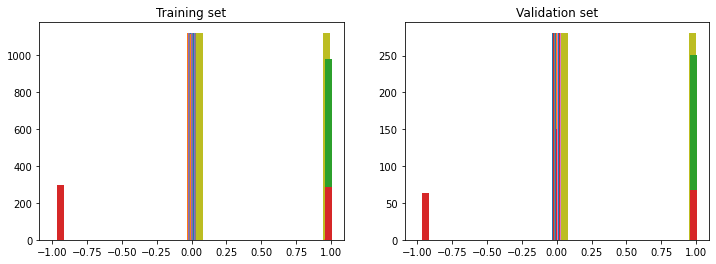

In [29]:
num_bins=25
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=num_bins, width=0.05)
axes[0].set_title('Training set')
axes[1].hist(y_valid, bins=num_bins, width=0.05)
axes[1].set_title('Validation set')

We begin the train part

## Train Image part ( 4 Dimensional)

In [30]:
X_image = np.array([df_to_numpy_image(X_train,i) for i in X_train.index])

In [31]:
X_image.shape
#(1120, 270, 480, 3)

(1120, 270, 480, 3)

In [32]:
#(101, 270, 480, 3)  We choose only the imagen part of the train data, 
#There are 1120 picturtes with resolutionn WIDTH = 480 and HEIGHT = 270 with 3 colors rgb

In [33]:
# We perform the reshape

numpy.reshape(a, newshape, order='C')

- a - Array to be reshaped.
- newshape  - The new shape should be compatible with the original shape.

- order- Read the elements of a using this index order, and place the elements into the reshaped array using this index order.

Gives a new shape to an array without changing its data.

In [34]:
WIDTH = 480
HEIGHT = 270

Using arr.reshape() will give a new shape to an array without changing the data. Just remember that when you use the reshape method, the array you want to produce needs to have the same number of elements as the original array.

If you start with an array with N elements, you’ll need to make sure that your new array also has a total of N elements

You can use reshape() to reshape your array. 



![title](np_reshape.png)

With np.reshape, you can specify a few optional parameters:
np.reshape(a, newshape=(d, e), order='C')

a is the array to be reshaped.

newshape is the new shape you want. You can specify an integer or a tuple of integers. If you specify an integer, the result will be an array of that length. The shape should be compatible with the original shape.

order: C means to read/write the elements using C-like index order, F means to read/write the elements using Fortran-like index order, A means to read/write the elements in Fortran-like index order if a is Fortran contiguous in memory, C-like order otherwise. (This is an optional parameter and doesn’t need to be specified.)

If you want to learn more about C and Fortran order, you can read more about the internal organization of NumPy arrays here. Essentially, C and Fortran orders have to do with how indices correspond to the order the array is stored in memory. In Fortran, when moving through the elements of a two-dimensional array as it is stored in memory, the first index is the most rapidly varying index. As the first index moves to the next row as it changes, the matrix is stored one column at a time. This is why Fortran is thought of as a Column-major language. In C on the other hand, the last index changes the most rapidly. The matrix is stored by rows, making it a Row-major language. What you do for C or Fortran depends on whether it’s more important to preserve the indexing convention or not reorder the data.

We will reshape  270, 480 to  480, 270

(101, 270, 480, 3) -> (101, 480, 270, 3)

What does -1 mean in numpy reshape? A numpy matrix can be reshaped into a vector using reshape function with parameter -1. The criterion to satisfy for providing the new shape is that 'The new shape should be compatible with the original shape'

numpy allow us to give one of new shape parameter as -1 (eg: (-1,WIDTH,HEIGHT,3) . It simply means that it is an unknown dimension and we want numpy to figure it out. And numpy will figure this by looking at the 'length of the array and remaining dimensions' and making sure it satisfies the above mentioned criteria

In [35]:
# For cleaned processed rgb
X=X_image.reshape(-1,WIDTH,HEIGHT,3)
X.shape
#(101, 480, 270, 3) # the first number may change between the range (0 ,500)

(1120, 480, 270, 3)

In [36]:
X.size

435456000

## Train Input part ( 1 Dimensional )

In [37]:
def df_to_numpy_input(df_input,index): 
    # flattening a 2d numpy array
    # into 1d array
    # and remove dtype at the end of numpy array
    lista=df_input.loc[[index]].values.tolist()
    arr=np.array(lista).ravel()
    return arr


In [38]:
Y = [df_to_numpy_input(y_train,i) for i in y_train.index]

In [39]:
Y[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [40]:
type(Y[0])

numpy.ndarray

In [41]:
len(Y)

1120

In [42]:
type(Y)

list

We begin the test part

## Test Image part ( 4 Dimensional)

In [43]:
test_image = np.array([df_to_numpy_image(X_valid,i) for i in X_valid.index])

In [44]:
type(test_image)

numpy.ndarray

In [45]:
test_image.ndim

4

In [46]:
test_image.shape
#(26, 270, 480, 3)

(281, 270, 480, 3)

numpy.reshape(a, newshape, order='C')

- a - Array to be reshaped.
- newshape  - The new shape should be compatible with the original shape.

- order- Read the elements of a using this index order, and place the elements into the reshaped array using this index order.

Gives a new shape to an array without changing its data.

In [47]:
#For processed
test_x=test_image.reshape(-1,WIDTH,HEIGHT,3)
test_x.shape
#(26, 480, 270, 3)

(281, 480, 270, 3)

## Test Input part

In [48]:
test_y = [df_to_numpy_input(y_valid,i) for i in y_valid.index]

In [49]:
#FILE_I_END = 1860
FILE_I_END = 2
WIDTH = 480
HEIGHT = 270
LR = 1e-3
#EPOCHS = 30
EPOCHS = 1
MODEL_NAME = 'model_mmo0/test'
PREV_MODEL = ''
LOAD_MODEL = True

wl = 0
sl = 0
al = 0
dl = 0

wal = 0
wdl = 0
sal = 0
sdl = 0
nkl = 0

w = [1,0,0,0,0,0,0,0,0]
s = [0,1,0,0,0,0,0,0,0]
a = [0,0,1,0,0,0,0,0,0]
d = [0,0,0,1,0,0,0,0,0]
wa = [0,0,0,0,1,0,0,0,0]
wd = [0,0,0,0,0,1,0,0,0]
sa = [0,0,0,0,0,0,1,0,0]
sd = [0,0,0,0,0,0,0,1,0]
nk = [0,0,0,0,0,0,0,0,1]

In [50]:
len(nk )

9

In [51]:
size=[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0]

In [52]:
len(size)

29

In [ ]:
# =============================================================================
# Create PyTorch Model
# =============================================================================

# Model configuration
MODEL_NAME = 'efficientnet_lstm'  # Options: efficientnet_lstm, mobilenet_v3, etc.
NUM_ACTIONS = 29
TEMPORAL_FRAMES = 4

# Training hyperparameters
EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

# Paths
MODEL_DIR = Path('model_mmo0')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = TEMPORAL_FRAMES if is_temporal else 1

print(f"Creating model: {MODEL_NAME}")
print(f"  Temporal: {is_temporal} (seq_len={seq_len})")

# Create model
model = get_model(
    MODEL_NAME,
    num_actions=NUM_ACTIONS,
    temporal_frames=seq_len,
    pretrained=True
)
model = model.to(device)
print(f"  Parameters: {count_parameters(model):,}")

In [ ]:
# =============================================================================
# PyTorch Training Loop (Simple Version)
# =============================================================================

# Create PyTorch Dataset for pandas DataFrame data
class CleanedDataset(Dataset):
    """PyTorch Dataset for cleaned pandas DataFrame data."""
    
    def __init__(self, X_images, Y_labels, seq_len=1):
        """
        Args:
            X_images: numpy array of shape (N, H, W, C)
            Y_labels: list of numpy arrays, each shape (num_actions,)
            seq_len: sequence length for temporal models
        """
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        # Get sequence of frames
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        
        # Get action for last frame
        action = self.actions[idx + self.seq_len - 1]
        
        # Convert to tensor (NCHW format for PyTorch)
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2)  # (seq, C, H, W)
        frames = frames / 255.0  # Normalize to [0, 1]
        
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

# Create datasets
train_dataset = CleanedDataset(X, Y, seq_len=seq_len)
val_dataset = CleanedDataset(test_x, test_y, seq_len=seq_len)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

# Train for one epoch
model.train()
total_loss = 0.0
for batch_idx, (frames, actions) in enumerate(train_loader):
    frames = frames.to(device)
    actions = actions.to(device)
    
    optimizer.zero_grad()
    outputs = model(frames)
    loss = criterion(outputs, actions)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    total_loss += loss.item()
    if (batch_idx + 1) % 10 == 0:
        print(f"  Batch {batch_idx + 1}/{len(train_loader)} - Loss: {loss.item():.4f}")

avg_train_loss = total_loss / len(train_loader)

# Validation
model.eval()
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for frames, actions in val_loader:
        frames = frames.to(device)
        actions = actions.to(device)
        
        outputs = model(frames)
        loss = criterion(outputs, actions)
        val_loss += loss.item()
        
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == actions).all(dim=1).sum().item()
        total += actions.size(0)

avg_val_loss = val_loss / len(val_loader)
val_acc = correct / total if total > 0 else 0.0

print(f"\nEpoch Summary:")
print(f"  Train Loss: {avg_train_loss:.4f}")
print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

In [ ]:
# Save the trained model (PyTorch)
save_model(model, str(MODEL_PATH), model_name=MODEL_NAME)
print(f"Model saved to {MODEL_PATH}")

In [56]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)

In [ ]:
restartkernel()

## Full code 1 - Draft simple big test

In [ ]:
# =============================================================================
# Full Code 1 - Draft Simple Big Test (PyTorch Version)
# =============================================================================
# This example trains on a single big cleaned data file

import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Local imports
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Configuration
FILE_I_END = 1  # Single big file
WIDTH = 480
HEIGHT = 270
EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MODEL_NAME = 'efficientnet_lstm'
NUM_ACTIONS = 29
MODEL_DIR = Path('model_mmo1')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'
LOAD_MODEL = False

# Device setup
device = get_device()
print(f"Using device: {device}")

# Helper functions for DataFrame conversion
def df_to_numpy_input(df_input, index): 
    lista = df_input.loc[[index]].values.tolist()
    arr = np.array(lista).ravel()
    return arr

def df_to_numpy_image(df_image_clean, index):
    image_clean = df_image_clean.loc[[index]].T.to_numpy()
    lists = image_clean.tolist()
    matrix = lists
    flatten_matrix = [val.tolist() for sublist in matrix for val in sublist]
    arr = np.array(flatten_matrix)
    return arr

# PyTorch Dataset for cleaned DataFrame data
class CleanedDataset(Dataset):
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = 4 if is_temporal else 1

# Create model
print(f"Creating model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
model = model.to(device)
print(f"Parameters: {count_parameters(model):,}")

# Load previous model if requested
if LOAD_MODEL and MODEL_PATH.exists():
    model, _ = load_model(str(MODEL_PATH), device=device)
    print('Loaded previous model!')

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()

# Training loop
for e in range(EPOCHS):
    data_order = [i for i in range(1, FILE_I_END + 1)]
    shuffle(data_order)
    
    for count, i in enumerate(data_order):
        try:
            # Load cleaned big files           
            df_image_clean = pd.read_pickle('clean/data/x_training_data.csv')  
            df = pd.read_csv('clean/data/y_training_data.csv')  
            assert len(df) == len(df_image_clean), "Dimensions mismatch"
            
            # Train/test split
            X_train, X_valid, y_train, y_valid = train_test_split(
                df_image_clean, df, test_size=0.2, random_state=6
            )
            
            # Prepare data arrays
            X_image = np.array([df_to_numpy_image(X_train, i) for i in X_train.index])
            X = X_image.reshape(-1, WIDTH, HEIGHT, 3)
            Y = [df_to_numpy_input(y_train, i) for i in y_train.index]
            
            test_image = np.array([df_to_numpy_image(X_valid, i) for i in X_valid.index])
            test_x = test_image.reshape(-1, WIDTH, HEIGHT, 3)
            test_y = [df_to_numpy_input(y_valid, i) for i in y_valid.index]
            
            # Create dataloaders
            train_dataset = CleanedDataset(X, Y, seq_len=seq_len)
            val_dataset = CleanedDataset(test_x, test_y, seq_len=seq_len)
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Train epoch
            model.train()
            total_loss = 0.0
            for batch_idx, (frames, actions) in enumerate(train_loader):
                frames, actions = frames.to(device), actions.to(device)
                
                optimizer.zero_grad()
                outputs = model(frames)
                loss = criterion(outputs, actions)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            
            # Validate
            model.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for frames, actions in val_loader:
                    frames, actions = frames.to(device), actions.to(device)
                    outputs = model(frames)
                    loss = criterion(outputs, actions)
                    val_loss += loss.item()
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                    correct += (preds == actions).all(dim=1).sum().item()
                    total += actions.size(0)
            
            avg_train = total_loss / len(train_loader)
            avg_val = val_loss / len(val_loader) if len(val_loader) > 0 else 0
            val_acc = correct / total if total > 0 else 0
            
            print(f"Epoch {e+1}/{EPOCHS} - Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}, Val Acc: {val_acc:.4f}")
            
            # Save checkpoint
            if count % 10 == 0:
                print('SAVING MODEL!')
                save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=e)
                
        except Exception as ex:
            print(str(ex))
    
    scheduler.step()

print("Training complete!")
save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=EPOCHS-1)

In [4]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)

In [ ]:
restartkernel()

## Full code 2 multiple files

In [ ]:
# =============================================================================
# Full Code 2 - Multiple Files (PyTorch Version)
# =============================================================================
# This example trains on multiple small cleaned data files

import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Local imports
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Configuration
clean_label = False  # Set True to re-clean raw files
FILE_I_END = 30  # Multiple small files
WIDTH = 480
HEIGHT = 270
EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MODEL_NAME = 'efficientnet_lstm'
NUM_ACTIONS = 29
MODEL_DIR = Path('model_mmo2a')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'
LOAD_MODEL = False

# Device setup
device = get_device()
print(f"Using device: {device}")

# Helper functions
def df_to_numpy_input(df_input, index): 
    lista = df_input.loc[[index]].values.tolist()
    arr = np.array(lista).ravel()
    return arr

def df_to_numpy_image(df_image_clean, index):
    image_clean = df_image_clean.loc[[index]].T.to_numpy()
    lists = image_clean.tolist()
    matrix = lists
    flatten_matrix = [val.tolist() for sublist in matrix for val in sublist]
    arr = np.array(flatten_matrix)
    return arr

def cleaning_data(train_data, show=False):
    """Clean and balance the training data."""
    df = pd.DataFrame()
    for i in range(len(train_data)):
        row = list(train_data[i][1])
        temp = pd.DataFrame([row])
        df = pd.concat([df, temp])
    df = df.reset_index(drop=True)

    num_bins = 25
    threshold = (df[13] != 0).astype(int).sum(axis=0)
    samples_per_bin = threshold
    hist, bins = np.histogram(df[13], num_bins)
    center = (bins[:-1] + bins[1:]) * 0.5
    
    remove_list = []
    for j in range(num_bins):
        list_ = []
        for i in range(len(df[13])):
            serie = df[13].iloc[[i]]
            ls = serie.tolist()
            if ls[0] >= bins[j] and ls[0] <= bins[j+1]:
                list_.append(i)      
        list_ = list_[samples_per_bin:]
        remove_list.extend(list_)
        
    df.drop(df.index[remove_list], inplace=True)
    print('remaining:', len(df))
    df = df.reset_index(drop=True)
    
    if show:
        hist, _ = np.histogram(df[13], (num_bins))
        plt.bar(center, hist, width=0.05)
        plt.plot((np.min(df[13]), np.max(df[13])), (samples_per_bin, samples_per_bin))
    
    df_image = pd.DataFrame()
    for i in range(len(train_data)):
        row = list(train_data[i][0])
        temp = pd.DataFrame([row])
        df_image = pd.concat([df_image, temp])
    df_image = df_image.reset_index(drop=True)
    df_image_removed = df_image.drop(remove_list, axis=0, inplace=False)
    df_image_clean = df_image_removed.reset_index(drop=True)
    
    assert len(df) == len(df_image_clean), "Dimensions mismatch"
    return df_image_clean, df

# PyTorch Dataset
class CleanedDataset(Dataset):
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = 4 if is_temporal else 1

# Create model
print(f"Creating model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
model = model.to(device)
print(f"Parameters: {count_parameters(model):,}")

if LOAD_MODEL and MODEL_PATH.exists():
    model, _ = load_model(str(MODEL_PATH), device=device)
    print('Loaded previous model!')

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * FILE_I_END)
criterion = nn.BCEWithLogitsLoss()

# Training loop over multiple files
for e in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {e+1}/{EPOCHS}")
    print(f"{'='*60}")
    
    data_order = [i for i in range(1, FILE_I_END + 1)]
    shuffle(data_order)
    
    for count, i in enumerate(data_order):
        try:
            x_file_name = f'clean/x_training_data-{i}.csv'
            y_file_name = f'clean/y_training_data-{i}.csv'
            
            # Optionally re-clean raw data
            if clean_label:
                file_name = f'preprocessed_training_data-{i}.npy'
                print(file_name)
                train_data = np.load(file_name, allow_pickle=True)
                df_image_clean, df = cleaning_data(train_data, show=False)
                df_image_clean.to_pickle(x_file_name)
                df.to_csv(y_file_name, index=False)

            # Load cleaned files
            df_image_clean = pd.read_pickle(x_file_name)  
            df = pd.read_csv(y_file_name)  
            assert len(df) == len(df_image_clean), "Dimensions mismatch"
            
            # Split data
            X_train, X_valid, y_train, y_valid = train_test_split(
                df_image_clean, df, test_size=0.2, random_state=6
            )
            
            # Prepare arrays
            X_image = np.array([df_to_numpy_image(X_train, idx) for idx in X_train.index])
            X = X_image.reshape(-1, WIDTH, HEIGHT, 3)
            Y = [df_to_numpy_input(y_train, idx) for idx in y_train.index]
            
            test_image = np.array([df_to_numpy_image(X_valid, idx) for idx in X_valid.index])
            test_x = test_image.reshape(-1, WIDTH, HEIGHT, 3)
            test_y = [df_to_numpy_input(y_valid, idx) for idx in y_valid.index]
            
            # Create dataloaders
            train_dataset = CleanedDataset(X, Y, seq_len=seq_len)
            val_dataset = CleanedDataset(test_x, test_y, seq_len=seq_len)
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Train
            model.train()
            total_loss = 0.0
            for frames, actions in train_loader:
                frames, actions = frames.to(device), actions.to(device)
                optimizer.zero_grad()
                outputs = model(frames)
                loss = criterion(outputs, actions)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            
            # Validate
            model.eval()
            val_loss = 0.0
            correct = 0
            total_samples = 0
            with torch.no_grad():
                for frames, actions in val_loader:
                    frames, actions = frames.to(device), actions.to(device)
                    outputs = model(frames)
                    loss = criterion(outputs, actions)
                    val_loss += loss.item()
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                    correct += (preds == actions).all(dim=1).sum().item()
                    total_samples += actions.size(0)
            
            avg_train = total_loss / len(train_loader) if len(train_loader) > 0 else 0
            avg_val = val_loss / len(val_loader) if len(val_loader) > 0 else 0
            val_acc = correct / total_samples if total_samples > 0 else 0
            
            print(f"  File {i:2d} - Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}, Val Acc: {val_acc:.4f}")
            
            scheduler.step()
            
            if count % 10 == 0:
                print('  SAVING MODEL!')
                save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=e)
                
        except Exception as ex:
            print(f"  Error with file {i}: {str(ex)}")

print("\nTraining complete!")
save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=EPOCHS-1)

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)

In [ ]:
restartkernel()

## Full code 3 - Single big file

In [ ]:
# =============================================================================
# Full Code 3 - Single Big File (PyTorch Version)
# =============================================================================
# This example trains on a single large cleaned dataset for multiple epochs

import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Local imports
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Configuration
WIDTH = 480
HEIGHT = 270
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MODEL_NAME = 'efficientnet_lstm'
NUM_ACTIONS = 29
MODEL_DIR = Path('model_mmo3')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'
LOAD_MODEL = False

# Device setup
device = get_device()
print(f"Using device: {device}")

# Helper functions
def df_to_numpy_input(df_input, index): 
    lista = df_input.loc[[index]].values.tolist()
    arr = np.array(lista).ravel()
    return arr

def df_to_numpy_image(df_image_clean, index):
    image_clean = df_image_clean.loc[[index]].T.to_numpy()
    lists = image_clean.tolist()
    flatten_matrix = [val.tolist() for sublist in lists for val in sublist]
    arr = np.array(flatten_matrix)
    return arr

# PyTorch Dataset
class CleanedDataset(Dataset):
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = 4 if is_temporal else 1

# Create model
print(f"Creating model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
model = model.to(device)
print(f"Parameters: {count_parameters(model):,}")

if LOAD_MODEL and MODEL_PATH.exists():
    model, _ = load_model(str(MODEL_PATH), device=device)
    print('Loaded previous model!')

# Load cleaned big files           
print("Loading data...")
df_image_clean = pd.read_pickle('clean/data/x_training_data.csv')  
df = pd.read_csv('clean/data/y_training_data.csv')  
assert len(df) == len(df_image_clean), "Dimensions mismatch"
print(f"Loaded {len(df)} samples")

# Train/test split
X_train, X_valid, y_train, y_valid = train_test_split(
    df_image_clean, df, test_size=0.2, random_state=6
)

# Prepare data arrays
print("Preparing arrays...")
X_image = np.array([df_to_numpy_image(X_train, i) for i in X_train.index])
X = X_image.reshape(-1, WIDTH, HEIGHT, 3)
Y = [df_to_numpy_input(y_train, i) for i in y_train.index]

test_image = np.array([df_to_numpy_image(X_valid, i) for i in X_valid.index])
test_x = test_image.reshape(-1, WIDTH, HEIGHT, 3)
test_y = [df_to_numpy_input(y_valid, i) for i in y_valid.index]

print(f"Train: {len(X)} samples, Val: {len(test_x)} samples")

# Create dataloaders
train_dataset = CleanedDataset(X, Y, seq_len=seq_len)
val_dataset = CleanedDataset(test_x, test_y, seq_len=seq_len)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()

# Training history
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"\nStarting training for {EPOCHS} epochs...")
print(f"{'='*60}")

try:
    for epoch in range(EPOCHS):
        # Training phase
        model.train()
        total_loss = 0.0
        for frames, actions in train_loader:
            frames, actions = frames.to(device), actions.to(device)
            
            optimizer.zero_grad()
            outputs = model(frames)
            loss = criterion(outputs, actions)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for frames, actions in val_loader:
                frames, actions = frames.to(device), actions.to(device)
                outputs = model(frames)
                loss = criterion(outputs, actions)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == actions).all(dim=1).sum().item()
                total += actions.size(0)
        
        avg_train = total_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        val_acc = correct / total if total > 0 else 0
        
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d}/{EPOCHS} - Loss: {avg_train:.4f} - Val Loss: {avg_val:.4f} - Val Acc: {val_acc:.4f}")
        
        # Save best model
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            save_model(model, str(MODEL_DIR / f'{MODEL_NAME}_best.pth'), 
                      optimizer=optimizer, epoch=epoch, loss=avg_val)
        
        scheduler.step()
    
    print('SAVING MODEL!')
    save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=EPOCHS-1)
    
except Exception as e:
    print(str(e))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Training/Validation Loss')

axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Validation Accuracy')
plt.tight_layout()
plt.show()

In [1]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)

In [ ]:
restartkernel()

## Full code 4 - Single big file with oversampling

In [ ]:
# =============================================================================
# Full Code 4 - Single Big File with Undersampling (PyTorch Version)
# =============================================================================
# This example trains on undersampled/balanced data to handle class imbalance

import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Local imports
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Configuration
WIDTH = 480
HEIGHT = 270
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MODEL_NAME = 'efficientnet_lstm'
NUM_ACTIONS = 29
MODEL_DIR = Path('model_mmo4')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'
LOAD_MODEL = False

# Device setup
device = get_device()
print(f"Using device: {device}")

# Helper functions
def df_to_numpy_input(df_input, index): 
    lista = df_input.loc[[index]].values.tolist()
    arr = np.array(lista).ravel()
    return arr

def df_to_numpy_image(df_image_clean, index):
    image_clean = df_image_clean.loc[[index]].T.to_numpy()
    lists = image_clean.tolist()
    flatten_matrix = [val.tolist() for sublist in lists for val in sublist]
    arr = np.array(flatten_matrix)
    return arr

# PyTorch Dataset
class CleanedDataset(Dataset):
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = 4 if is_temporal else 1

# Create model
print(f"Creating model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
model = model.to(device)
print(f"Parameters: {count_parameters(model):,}")

if LOAD_MODEL and MODEL_PATH.exists():
    model, _ = load_model(str(MODEL_PATH), device=device)
    print('Loaded previous model!')

# Load cleaned big files with undersampling       
print("Loading undersampled data...")
df_image_clean = pd.read_pickle('clean/data/undersampling/x_training_data.csv')  
df = pd.read_csv('clean/data/undersampling/y_training_data.csv')  
assert len(df) == len(df_image_clean), "Dimensions mismatch"
print(f"Loaded {len(df)} samples (undersampled for class balance)")

# Train/test split
X_train, X_valid, y_train, y_valid = train_test_split(
    df_image_clean, df, test_size=0.2, random_state=6
)

# Prepare data arrays
print("Preparing arrays...")
X_image = np.array([df_to_numpy_image(X_train, i) for i in X_train.index])
X = X_image.reshape(-1, WIDTH, HEIGHT, 3)
Y = [df_to_numpy_input(y_train, i) for i in y_train.index]

test_image = np.array([df_to_numpy_image(X_valid, i) for i in X_valid.index])
test_x = test_image.reshape(-1, WIDTH, HEIGHT, 3)
test_y = [df_to_numpy_input(y_valid, i) for i in y_valid.index]

print(f"Train: {len(X)} samples, Val: {len(test_x)} samples")

# Create dataloaders
train_dataset = CleanedDataset(X, Y, seq_len=seq_len)
val_dataset = CleanedDataset(test_x, test_y, seq_len=seq_len)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()

# Training history
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"\nStarting training for {EPOCHS} epochs...")
print(f"{'='*60}")

try:
    for epoch in range(EPOCHS):
        # Training phase
        model.train()
        total_loss = 0.0
        for frames, actions in train_loader:
            frames, actions = frames.to(device), actions.to(device)
            
            optimizer.zero_grad()
            outputs = model(frames)
            loss = criterion(outputs, actions)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for frames, actions in val_loader:
                frames, actions = frames.to(device), actions.to(device)
                outputs = model(frames)
                loss = criterion(outputs, actions)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == actions).all(dim=1).sum().item()
                total += actions.size(0)
        
        avg_train = total_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        val_acc = correct / total if total > 0 else 0
        
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d}/{EPOCHS} - Loss: {avg_train:.4f} - Val Loss: {avg_val:.4f} - Val Acc: {val_acc:.4f}")
        
        # Save best model
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            save_model(model, str(MODEL_DIR / f'{MODEL_NAME}_best.pth'), 
                      optimizer=optimizer, epoch=epoch, loss=avg_val)
        
        scheduler.step()
    
    print('SAVING MODEL!')
    save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=EPOCHS-1)
    
except Exception as e:
    print(str(e))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Training/Validation Loss')

axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Validation Accuracy')
plt.tight_layout()
plt.show()

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Model saved to: {MODEL_PATH}")

## TensorBoard in Terminal

In [9]:
#pip install tensorboard

After the learning step has completed, you can just open a terminal and enter the command below
$ tensorboard --logdir='/tmp/tflearn_logs'

tensorboard --logdir='/log/model_clean/test'

I have to be sure that model = tflearn.DNN(network, checkpoint_path='/tmp/tflearn_logs/',max_checkpoints=1, tensorboard_verbose=0) By adjusting tensorboard_variable, we tell  Tflearn to save metrics that Tensorboard will master later.


## TensorBoard in Jupyter Notebook

TensorBoard is a great tool providing visualization of many metrics necessary to evaluate TensorFlow model training. It used to be difficult to bring up this tool especially in a hosted Jupyter Notebook environment such as Google Colab, Kaggle notebook and Coursera's Notebook etc. 

Start by installing TF 2.0 and loading the TensorBoard notebook extension:

![title](img/result1.jpg)

![title](img/result2.jpg)

In [12]:
#!pip install -q tf-nightly

In [1]:
import tensorflow as tf
import datetime, os

In [6]:
#pip install tensorboard

In [7]:
#pip uninstall tensorboard

In [ ]:
#pip install tf-nightly

In [8]:
#pip uninstall tf-nightly

In [9]:
#pip install --force-reinstall tf-nightly

In [ ]:
# Load the TensorBoard notebook extension

In [1]:
%load_ext tensorboard
%tensorboard --logdir log

Reusing TensorBoard on port 6006 (pid 13600), started 6:09:22 ago. (Use '!kill 13600' to kill it.)

The same TensorBoard backend is reused by issuing the same command. If a different logs directory was chosen, a new instance of TensorBoard would be opened. Ports are managed automatically.

Any new interesting feature worth mentioning is the "conceptual graph". To see the conceptual graph, select the “keras” tag. For this example, you’ll see a collapsed Sequential node. Double-click the node to see the model’s structure:

## Alternative Approaches with PyTorch

This notebook now uses **PyTorch 2.x** instead of TensorFlow/TFLearn. You can easily switch between different model architectures by changing the `MODEL_NAME` variable.

### Available PyTorch Models

| Model | Size | Parameters | Temporal | Speed | Use Case |
|-------|------|-----------|----------|-------|----------|
| **efficientnet_lstm** | ~20MB | ~5M | Yes | Medium | Best accuracy with temporal awareness |
| **efficientnet_simple** | ~15MB | ~4M | No | Fast | Single-frame predictions |
| **mobilenet_v3** | ~10MB | ~2M | No | Fastest | Low-end hardware / real-time |
| **resnet18_lstm** | ~50MB | ~12M | Yes | Medium | Good balance of speed/accuracy |
| **inception_v3** | ~30MB | ~7M | No | Slow | Legacy (ported from TFLearn) |
| **alexnet** | ~230MB | ~60M | No | Medium | Legacy (ported from TFLearn) |

### Why PyTorch?

- **Modern framework**: Active development, large community
- **Smaller bundle**: ~200MB vs TensorFlow's ~600MB
- **Better debugging**: Dynamic graphs, clearer error messages
- **TorchScript**: Easy deployment and optimization